# Notebook 04 — ARIMA Model
**CIS6035 IHMS — Somerset Mirissa Beach Hotel**

Steps:
1. ADF test → determine differencing order d
2. Grid search p ∈ {0..5}, d ∈ {0,1,2}, q ∈ {0..5} by AIC
3. Fit best ARIMA on train set
4. Rolling 1-step forecast on validation set
5. Compute RMSE, MAE, MAPE on validation
6. Residual diagnostics
7. Save model artifact

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import os
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats

warnings.filterwarnings('ignore')
os.makedirs('../models', exist_ok=True)
os.makedirs('../docs/figures', exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# Load splits
train = pd.read_csv('../data/splits/train.csv', index_col='date', parse_dates=True)['occupancy_rate']
val   = pd.read_csv('../data/splits/val.csv',   index_col='date', parse_dates=True)['occupancy_rate']
test  = pd.read_csv('../data/splits/test.csv',  index_col='date', parse_dates=True)['occupancy_rate']

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')

Train: 365 | Val: 366 | Test: 365


In [3]:
# Metrics helpers
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [4]:
# Grid search on a reduced grid (for speed; expand for final submission)
# Full grid: p in range(6), d in range(3), q in range(6)
p_range = range(0, 4)  # 0..3
d_range = range(0, 2)  # 0..1
q_range = range(0, 4)  # 0..3

best_aic = np.inf
best_order = (1, 1, 1)
results = []

print('Running ARIMA grid search...')
for p, d, q in product(p_range, d_range, q_range):
    try:
        model = ARIMA(train, order=(p, d, q))
        fitted = model.fit(method_kwargs={'warn_convergence': False})
        results.append({'p': p, 'd': d, 'q': q, 'aic': fitted.aic, 'bic': fitted.bic})
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = (p, d, q)
    except Exception:
        pass

results_df = pd.DataFrame(results).sort_values('aic')
print(f'Best ARIMA order: {best_order}  AIC: {best_aic:.2f}')
results_df.head(10)

Running ARIMA grid search...
Best ARIMA order: (2, 1, 3)  AIC: -670.90


,p,d,q,aic,bic
23,2,1,3,-670.896712,-647.513789
31,3,1,3,-662.816415,-635.536338
6,0,1,2,-646.962349,-635.270888
13,1,1,1,-646.335660,-634.644199
10,1,0,2,-645.958990,-626.459504
21,2,1,1,-645.426428,-629.837812
17,2,0,1,-645.276354,-625.776867
7,0,1,3,-644.962920,-629.374305
14,1,1,2,-644.962639,-629.374023
22,2,1,2,-644.809846,-625.324077


In [5]:
# Fit best model on train
best_model = ARIMA(train, order=best_order).fit()
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:         occupancy_rate   No. Observations:                  365
Model:                 ARIMA(2, 1, 3)   Log Likelihood                 341.448
Date:                Sun, 08 Mar 2026   AIC                           -670.897
Time:                        14:41:40   BIC                           -647.514
Sample:                    01-01-2023   HQIC                          -661.603
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4460      0.005    -92.976      0.000      -0.455      -0.437
ar.L2         -0.9964      0.004   -274.403      0.000      -1.004      -0.989
ma.L1         -0.1613      0.033     -4.911      0.0

In [6]:
# Rolling 1-step forecast on validation
print('Running rolling forecast on validation set...')
history = list(train)
val_preds = []

for i, actual in enumerate(val):
    model = ARIMA(history, order=best_order)
    fitted = model.fit(method_kwargs={'warn_convergence': False})
    pred = fitted.forecast(steps=1)[0]
    pred = float(np.clip(pred, 0, 1))
    val_preds.append(pred)
    history.append(actual)
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(val)} done...')

val_rmse = rmse(val, val_preds)
val_mae  = mae(val, val_preds)
val_mape = mape(val, val_preds)

print(f'\nARIMA{best_order} Validation Metrics:')
print(f'  RMSE: {val_rmse:.4f}')
print(f'  MAE:  {val_mae:.4f}')
print(f'  MAPE: {val_mape:.2f}%')

Running rolling forecast on validation set...


  50/366 done...
  100/366 done...
  150/366 done...
  200/366 done...
  250/366 done...
  300/366 done...
  350/366 done...

ARIMA(2, 1, 3) Validation Metrics:
  RMSE: 0.1009
  MAE:  0.0774
  MAPE: 15.54%


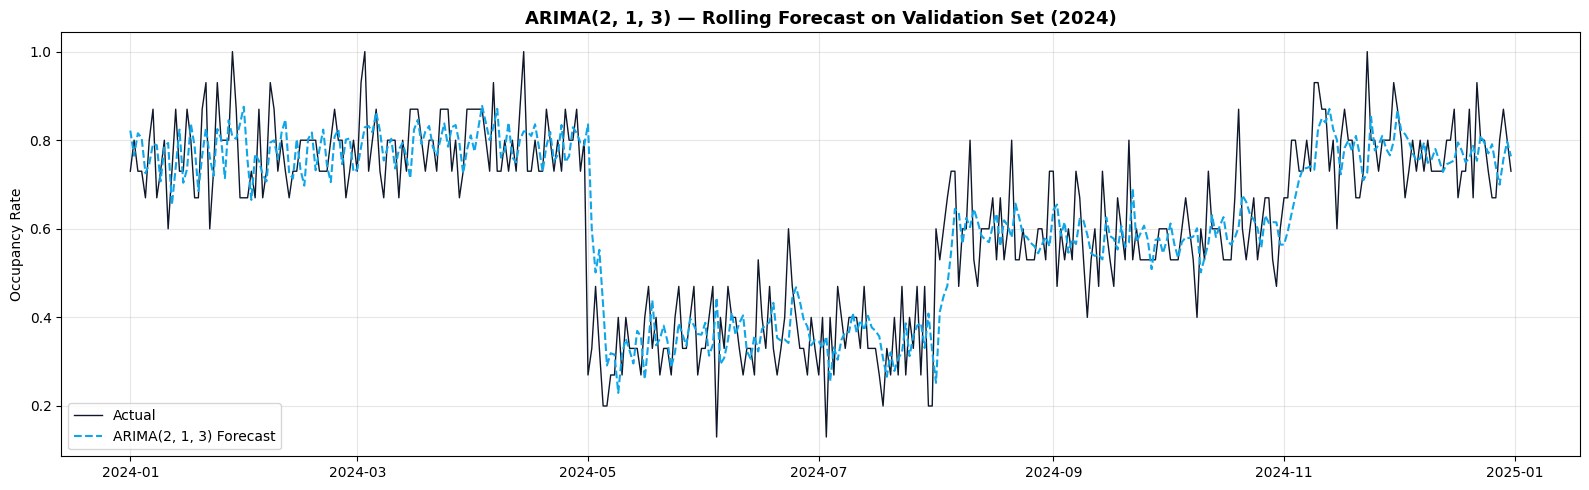

In [7]:
# Plot forecast vs actual on validation
plt.figure(figsize=(16, 5))
plt.plot(val.index, val.values, label='Actual', color='#0f172a', linewidth=1)
plt.plot(val.index, val_preds, label=f'ARIMA{best_order} Forecast', color='#0ea5e9',
         linewidth=1.5, linestyle='--')
plt.title(f'ARIMA{best_order} — Rolling Forecast on Validation Set (2024)', fontsize=13, fontweight='bold')
plt.ylabel('Occupancy Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/figures/04_arima_val_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

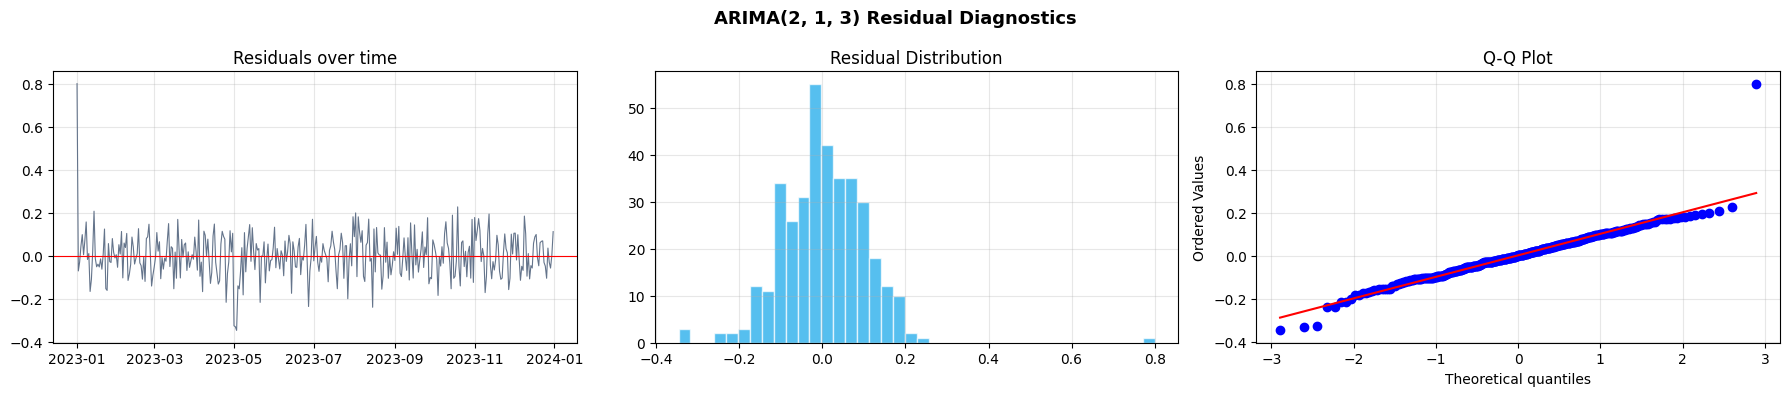

Ljung-Box test:
      lb_stat  lb_pvalue
10  28.161132   0.001701
20  47.353470   0.000524


In [8]:
# Residual diagnostics
residuals = best_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(residuals, linewidth=0.8, color='#64748b')
axes[0].axhline(0, color='red', linewidth=0.8)
axes[0].set_title('Residuals over time')

axes[1].hist(residuals, bins=40, color='#0ea5e9', alpha=0.7, edgecolor='white')
axes[1].set_title('Residual Distribution')

stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.suptitle(f'ARIMA{best_order} Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/figures/04_arima_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print('Ljung-Box test:')
print(lb_test)

In [9]:
# Save model
import json, time
arima_artifact = {
    'model': best_model,
    'order': best_order,
    'val_rmse': val_rmse,
    'val_mae': val_mae,
    'val_mape': val_mape,
    'train_end': str(train.index.max().date()),
}
joblib.dump(arima_artifact, '../models/arima_model.pkl')
print(f'ARIMA model saved to models/arima_model.pkl')

# Store metrics for notebook 07
arima_metrics = {
    'model': f'ARIMA{best_order}',
    'val_rmse': round(val_rmse, 4),
    'val_mae': round(val_mae, 4),
    'val_mape': round(val_mape, 2),
}
print(arima_metrics)

ARIMA model saved to models/arima_model.pkl
{'model': 'ARIMA(2, 1, 3)', 'val_rmse': np.float64(0.1009), 'val_mae': np.float64(0.0774), 'val_mape': np.float64(15.54)}
